In [4]:
## fitting on smooth - xdag

# FITTING
from scipy.optimize import curve_fit
import numpy as np 
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
plt.style.use('default')

kT = 4.11 #pN 
z = np.linspace(-4, 39, 350) 
lc, lp = 45, 0.5 #nm
F = 8 #pN

def F_wlc(dz, lc= 45, lp= 0.5):
    Fwlc = (kT / lp) * (1 / 4 * (1 - dz / lc)**(-2) + dz / lc - 1/4)
    return Fwlc
def U_wlc(z, F, lc, lp):
    U = (kT / lp) * (-0.25 * (lc**2) / (z - lc) + z**2 / (2 * lc) - 0.25 * z) - F * z
    return U
def U_fold_fit(z, a, G0, U0, s, x_dag):
    return U0 * (1 - np.exp(-a * z))**2 + G0 * np.exp(-((z - x_dag)**2) / s)
def U_total_fit(z, a, G0, U0, s, x_dag, lc, lp):
    offset = U_wlc(z, F, lc, lp)[0]  # F deve essere definito globalmente o passato
    return U_wlc(z, F, lc, lp) - offset + U_fold_fit(z, a, G0, U0, s, x_dag)

## print Morse / Morse + dG 

[2.31732031e-01 1.07022786e+02 8.74200495e+01 4.28319315e+02
 3.82153462e+01 5.00000000e+01 1.00000000e+00]
Minima positions (x): [ 1.12 19.82]
Minima values (y): [0.15343431 5.34858718]
Maxima position (x): 8.379999999999995
Maxima value (y): 15.27517039710932
Minima position of real data x): [18.94 20.04]


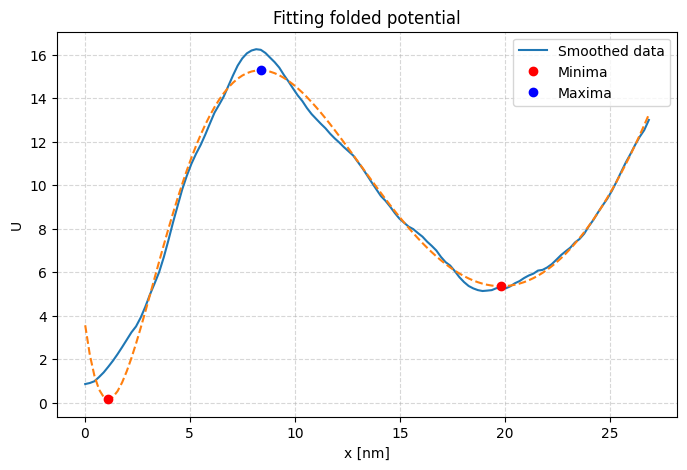

rho =  0.6346153846153841


In [5]:

#------------------------------------
F = 8
a, G0, U0, s, x_dag, lc, lp=  0.12, 8, 52, 12, 13, 45, 0.5
p0 = [a, G0, U0, s, x_dag, lc, lp]  

#------------------------------------
# import real data 
df = pd.read_csv("Free_energy.txt", header=None, names=["U"])
x_values = -26.6 + 0.22 * np.arange(350)
df["x"] = x_values
x = df["x"]
y = df["U"]
y_smooth = savgol_filter(y, window_length=15, polyorder=3)

x = np.array(x)
y_smooth = np.array(y_smooth)

# fit mask : optimize the fit 
mask = (x > 0)& (x < 27)
x_fit = x[mask]
y_fit = y_smooth[mask]

# Esempio: più peso nella regione centrale (8 < x < 14)
weights = np.ones_like(x_fit)
weights[(x_fit > 3) & (x_fit < 18)] = 2 
lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 40, 0.2]
upper_bounds = [ np.inf,  np.inf,  np.inf,  np.inf,  np.inf, 50, 1.0]

popt, pcov = curve_fit(U_total_fit, x_fit, y_fit, p0=p0, bounds= (lower_bounds, upper_bounds), sigma=1/weights, maxfev=10000)
p0 = [a, G0, U0, s, x_dag, lc, lp]  
a_fit, G0_fit, U0_fit, s_fit, x_dag_fit, lc_fit, lp_fit = popt
y_finalfit = U_total_fit(x_fit, *popt)

plt.figure(figsize=(8, 5))
plt.plot(x_fit, y_fit, label="Smoothed data")
plt.plot(x_fit, y_finalfit, linestyle="--")
plt.xlabel("x [nm]")
plt.ylabel("U")
plt.title("Fitting folded potential")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

print (popt)

minima_indices, _ = find_peaks(-y_finalfit)  
minima_indices = minima_indices[:2]
minima_x = x_fit[minima_indices]
minima_y = y_finalfit[minima_indices]

maxima_indices, _ = find_peaks(y_finalfit) 
maxima_x = x_fit[maxima_indices]
maxima_y = y_finalfit[maxima_indices]
#---------------------
# find minima of the real data
min, _ = find_peaks(-y_fit)  # Invert the signal to find minima
min = min[:2]  # Keep only the first two minima (if needed)
min_x = x_fit[min]
min_y = y_fit[min]

print("Minima positions (x):", minima_x)
print("Minima values (y):", minima_y)
print("Maxima position (x):", maxima_x[0])  
print("Maxima value (y):", maxima_y[0])
print("Minima position of real data x):", min_x)

plt.plot(minima_x , minima_y, "ro", label="Minima")
plt.plot(maxima_x, maxima_y, "bo", label="Maxima")
plt.legend()
plt.show()

X1 = np.abs(minima_x[0] - maxima_x[0])
X2 = np.abs(minima_x[1] - maxima_x[0])
# rho = (X1 + 1.12)/ (X2 - (19.82 - 18.94))
rho = X1/X2
print("rho = ", rho)

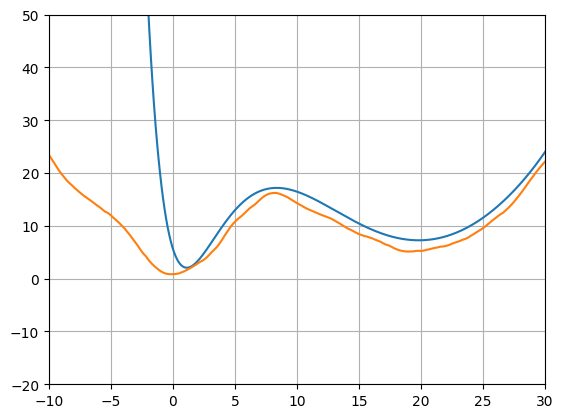

In [6]:
F = 8
E = U_total_fit(x_fit, *popt) 
offset = np.mean(E - y_fit)
E_check = U_total_fit(z,*popt) - offset
plt.plot(z, E_check+35 )
plt.plot(x, y_smooth)
# plt.plot(x_fit, y_fit)
plt.xlim(-10, 30)
plt.ylim(-20, 50)
plt.grid(True)


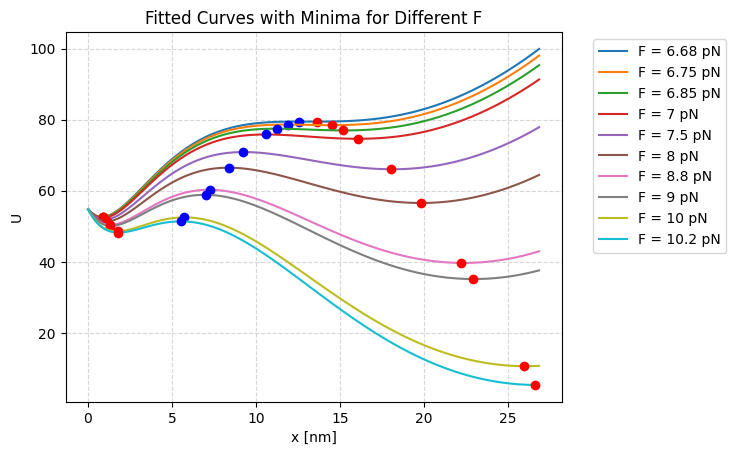

rho_list =  [10.600000000000058, 4.166666666666666, 2.611111111111116, 1.76, 0.9499999999999995, 0.6346153846153841, 0.39705882352941185, 0.3611111111111113, 0.19565217391304374, 0.17708333333333323]


In [7]:
# a_fit, G0_fit, U0_fit, s_fit, x_dag_fit, lc_fit, lp_fit = popt
# plt.plot(x_fit, U_total_fit(x_fit, *popt), label="Fitted curve")

F_list = (6.68, 6.75, 6.85,  7, 7.5, 8, 8.8,  9, 10, 10.2)
rho_list = []
X2_list = []
X1_list = []
maxima_list = []

for F in F_list:
    check = U_wlc(x_fit, F, lc_fit, lp_fit) + U_fold_fit(x_fit, a_fit, G0_fit, U0_fit, s_fit, x_dag_fit)

    minima_indices, _ = find_peaks(-check) 
    minima_x = x_fit[minima_indices]
    minima_y = check[minima_indices]

    maxima_indices, _ = find_peaks(check)  # Trova i massimi
    maxima_x = x_fit[maxima_indices]
    maxima_y = check[maxima_indices]
    maxima_list.append(maxima_x[0])
    
    plt.plot(x_fit, check, label=f'F = {F} pN')
    plt.plot(minima_x, minima_y, 'ro')
    plt.plot(maxima_x, maxima_y, 'bo')

    # compute rho
    X1 = np.abs(minima_x[0] - maxima_x[0])
    X2 = np.abs(minima_x[1] - maxima_x[0])
    X2_list.append(X2)
    X1_list.append(X1)
    rho = X1 / X2   
    rho_list.append(rho)
    
plt.xlabel("x [nm]")
plt.ylabel("U")
plt.title("Fitted Curves with Minima for Different F")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
print ("rho_list = ", rho_list)


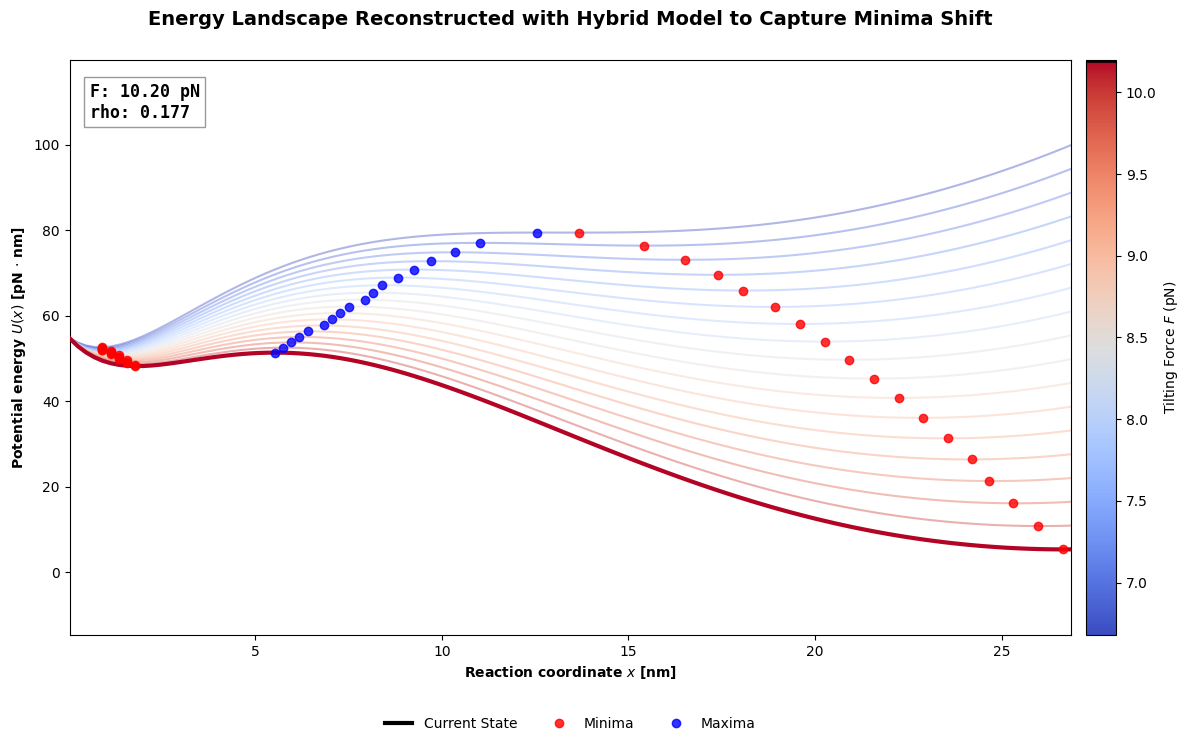

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FuncAnimation
from scipy.signal import find_peaks

# --- GENERAZIONE FLUIDA (100 STEP) ---
F_list_raw = sorted([6.68, 6.75, 6.85, 7, 7.5, 8, 8.8, 9, 10, 10.2])
F_list_fluid = np.linspace(np.min(F_list_raw), np.max(F_list_raw), 18) 

f_min, f_max = np.min(F_list_fluid), np.max(F_list_fluid)
cmap = plt.cm.coolwarm
norm = mpl.colors.Normalize(vmin=f_min, vmax=f_max)

fig, ax = plt.subplots(figsize=(12, 8))

# Titolo aggiornato richiesto
ax.set_title("Energy Landscape Reconstructed with Hybrid Model to Capture Minima Shift", 
             fontsize=14, pad=25, fontweight='bold')

# --- SETUP ASSI E COLORBAR ---
# Calcolo Y-limit preventivo per contenere tutto il tilt
y_extrema = []
for f_test in [f_min, f_max]:
    u_test = U_wlc(x_fit, f_test, lc_fit, lp_fit) + U_fold_fit(x_fit, a_fit, G0_fit, U0_fit, s_fit, x_dag_fit)
    y_extrema.extend([np.min(u_test), np.max(u_test)])
ax.set_ylim(np.min(y_extrema) - 20, np.max(y_extrema) + 20)
ax.set_xlim(np.min(x_fit), np.max(x_fit))

ax.set_xlabel("Reaction coordinate $x$ [nm]", fontweight='bold')
ax.set_ylabel("Potential energy $U(x)$ [pN $\cdot$ nm]", fontweight='bold')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.15)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"Tilting Force $F$ (pN)")

# --- ELEMENTI GRAFICI ---
# Aumentiamo lo spessore base (lw) per le linee "chiare" in mezzo
lines = [ax.plot([], [], color=cmap(norm(f)), lw=1.5, alpha=0)[0] for f in F_list_fluid]

current_line, = ax.plot([], [], color='black', lw=3, zorder=15, label='Current State')
minima_dots, = ax.plot([], [], 'ro', zorder=16, markersize=6, alpha=0.8, label='Minima')
maxima_dots, = ax.plot([], [], 'bo', zorder=16, markersize=6, alpha=0.8, label='Maxima')
cursor = cax.axhline(f_min, color='black', lw=4, xmin=-0.2, xmax=1.2, zorder=20)

rho_text = ax.text(0.02, 0.96, '', transform=ax.transAxes, fontsize=12, 
                   verticalalignment='top', family='monospace', fontweight='bold',
                   bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

h_min_x, h_min_y = [], []
h_max_x, h_max_y = [], []

def init():
    h_min_x.clear(); h_min_y.clear()
    h_max_x.clear(); h_max_y.clear()
    for l in lines: l.set_alpha(0)
    current_line.set_data([], [])
    return lines + [current_line, minima_dots, maxima_dots, cursor, rho_text]

def update(frame):
    F = F_list_fluid[frame]
    check = U_wlc(x_fit, F, lc_fit, lp_fit) + U_fold_fit(x_fit, a_fit, G0_fit, U0_fit, s_fit, x_dag_fit)
    
    # 1. RENDIAMO LA LINEA PERSISTENTE
    # Aumentiamo l'alfa a 0.4 per rendere le curve centrali meno "evanescenti"
    lines[frame].set_data(x_fit, check)
    lines[frame].set_alpha(0.4) 
    
    # 2. LINEA NERA SEMPRE SOPRA
    current_line.set_data(x_fit, check)
    current_line.set_color(cmap(norm(F)))
    
    # 3. PUNTI STAZIONARI
    min_idx, _ = find_peaks(-check)
    max_idx, _ = find_peaks(check)
    
    if len(min_idx) > 0:
        h_min_x.extend(x_fit[min_idx]); h_min_y.extend(check[min_idx])
    if len(max_idx) > 0:
        h_max_x.extend(x_fit[max_idx]); h_max_y.extend(check[max_idx])
    
    minima_dots.set_data(h_min_x, h_min_y)
    maxima_dots.set_data(h_max_x, h_max_y)
    
    # 4. INFO TEXT E CURSORE
    info = f'F: {F:.2f} pN'
    if len(min_idx) >= 2 and len(max_idx) >= 1:
        X1 = np.abs(x_fit[min_idx[0]] - x_fit[max_idx[0]])
        X2 = np.abs(x_fit[min_idx[1]] - x_fit[max_idx[0]])
        info += f'\nrho: {X1/X2:.3f}'
    rho_text.set_text(info)
    cursor.set_ydata([F])
    
    return [lines[frame], current_line, minima_dots, maxima_dots, cursor, rho_text]

# --- RENDER LENTO ---
ani = FuncAnimation(fig, update, frames=len(F_list_fluid), init_func=init, blit=False, repeat=True)

plt.tight_layout()
fig.subplots_adjust(bottom=0.2)

# Salvataggio con fps=12 (circa 8 secondi di video molto fluido)
ani.save('landscape_final_optimized.gif', writer='pillow', fps=5)

plt.show()

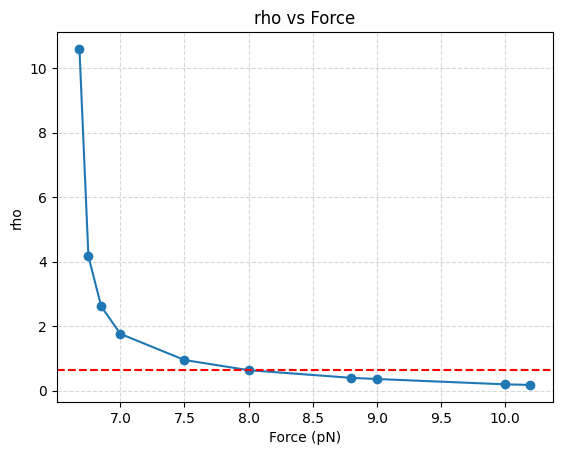

In [ ]:
colors = plt.get_cmap('tab10')
plt.plot(F_list, rho_list, 'o-', color = colors(0))
plt.axhline(y= 0.65, color='r', linestyle='--')
plt.xlabel("Force (pN)")
plt.ylabel("rho")    
plt.title("rho vs Force")   
plt.grid(True, linestyle="--", alpha=0.5)

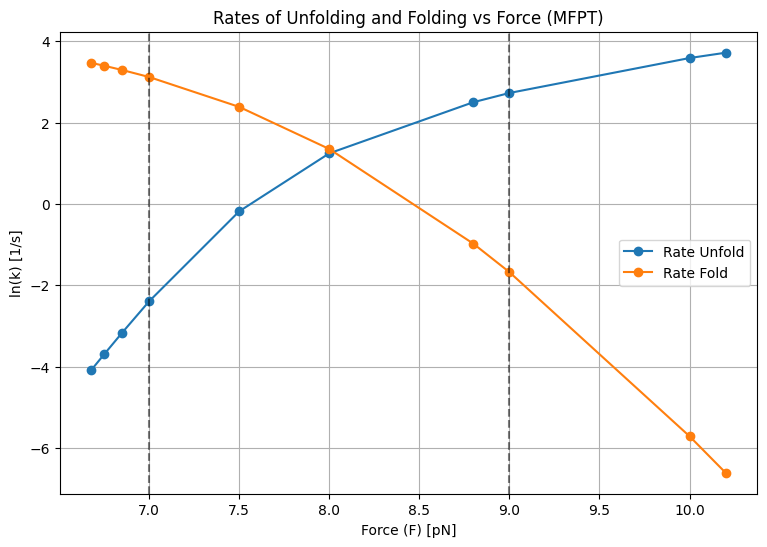

In [ ]:
# MFPT Simulation

from scipy.integrate import quad
D = 3000
kT = 4.11

def U_total_fit(z, a, G0, U0, s, x_dag, lc, lp, F):
    return U_wlc(z, F, lc, lp) + U_fold_fit(z, a, G0, U0, s, x_dag)


def mfpt(x, x_a, x_b, U_total_fit, kT, D, popt, F):    

    def inner_integral(y):
        result, _ = quad(lambda z: np.exp(-U_total_fit(z,  *popt, F) / kT), x_a, y)
        return result
    def outer_integral():
        result, _ = quad(lambda y: np.exp(U_total_fit(y, *popt, F) / kT) * inner_integral(y), x, x_b)
        return result

    return outer_integral() / D

rate_unfold_list = []
rate_fold_list = []
force_list = []
# F_list = [6.68, 6.75, 6.85,  7, 7.5, 8, 8.3, 8.4, 8.5, 8.6, 8.8, 9, 9.2, 9.3, 9.6, 10, 10.2]
F_list = (6.68, 6.75, 6.85,  7, 7.5, 8, 8.8,  9, 10, 10.2)

for F in F_list:

   #plt.plot(x_fit, U_total_fit(x_fit, *popt, F), label=f'F = {F} pN')
    mfpt_value = mfpt(minima_x[0], minima_x[0] - 1, minima_x[1], U_total_fit, kT, D, popt, F)
    rate_unfold = 1 / mfpt_value
    
    mfpt_value2 = mfpt(minima_x[1], minima_x[1] +1, minima_x[0], U_total_fit, kT, D, popt, F)
    rate_fold = 1 / mfpt_value2
    
    rate_unfold_list.append(rate_unfold)
    rate_fold_list.append(rate_fold)
    force_list.append(F)


plt.figure(figsize=(9, 6))
plt.plot(force_list, np.log(rate_unfold_list), label="Rate Unfold", marker='o')
plt.plot(force_list, np.log(rate_fold_list), label="Rate Fold", marker='o')
plt.axvline(x = 7, linestyle='--', c ="black",  alpha = 0.5)
plt.axvline(x = 9, linestyle='--', c ="black",  alpha = 0.5)
plt.xlabel("Force (F) [pN]")
plt.ylabel("ln(k) [1/s]")
plt.title("Rates of Unfolding and Folding vs Force (MFPT)")
plt.legend()
plt.grid(True)
plt.show()



UNFOLDING:
  slope = 2.2203
  x‡ (unfold) = 9.1254 nm


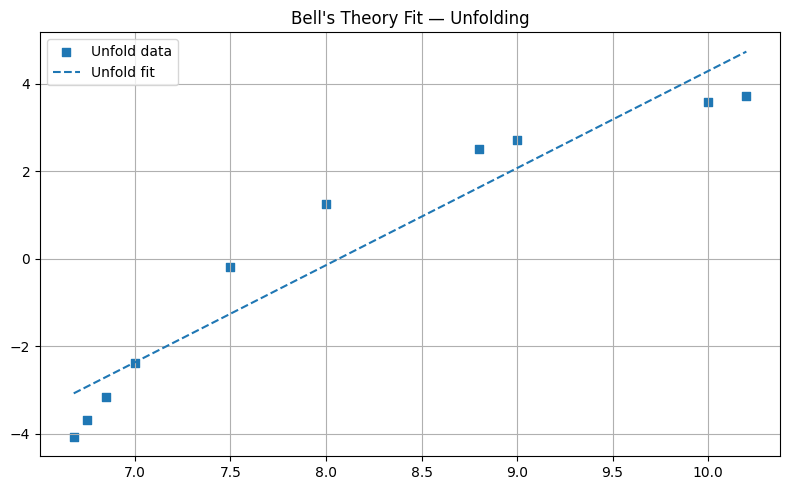


UNFOLDING:
  slope = 2.4296
  x‡ (unfold) = 9.9855 nm


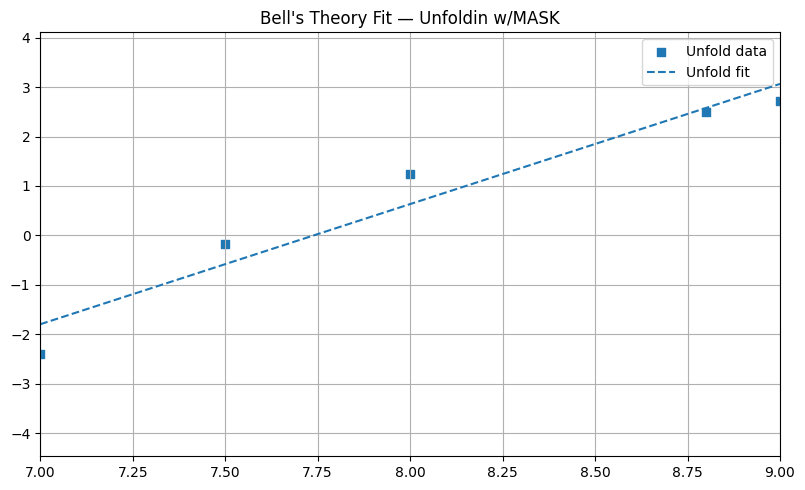

In [ ]:
# BELL'S MODEL FITTING - UNFOLD 
from scipy.stats import linregress

unfold_fit = linregress(force_list,np.log(rate_unfold_list))
x_dag_unfold = unfold_fit.slope * kT   
logk0_unfold = unfold_fit.intercept # rate at F = 0 == intercetta 

print("\nUNFOLDING:")
print(f"  slope = {unfold_fit.slope:.4f}")
print(f"  x‡ (unfold) = {x_dag_unfold:.4f} nm")

plt.figure(figsize=(8,5))
plt.scatter(force_list, np.log(rate_unfold_list), label="Unfold data", marker='s')
plt.plot(force_list, unfold_fit.intercept + unfold_fit.slope * np.array(force_list), label="Unfold fit", linestyle="--")
plt.title("Bell's Theory Fit — Unfolding")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#---- 
force_array = np.array(force_list)
rate_array = np.array(rate_unfold_list)

mask = (force_array >= 7) & (force_array <= 9)
force_filtered = force_array[mask]
rate_filtered = rate_array[mask]

unfold_fit = linregress(force_filtered, np.log(rate_filtered))
x_dag_unfold = unfold_fit.slope * kT
logk0_unfold = unfold_fit.intercept

print("\nUNFOLDING:")
print(f"  slope = {unfold_fit.slope:.4f}")
print(f"  x‡ (unfold) = {x_dag_unfold:.4f} nm")


plt.figure(figsize=(8,5))
plt.scatter(force_array, np.log(rate_array), label="Unfold data", marker='s')
plt.plot(force_filtered, unfold_fit.intercept + unfold_fit.slope * force_filtered, label="Unfold fit", linestyle="--")
plt.title("Bell's Theory Fit — Unfoldin w/MASK")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xlim(7, 9)
plt.show()

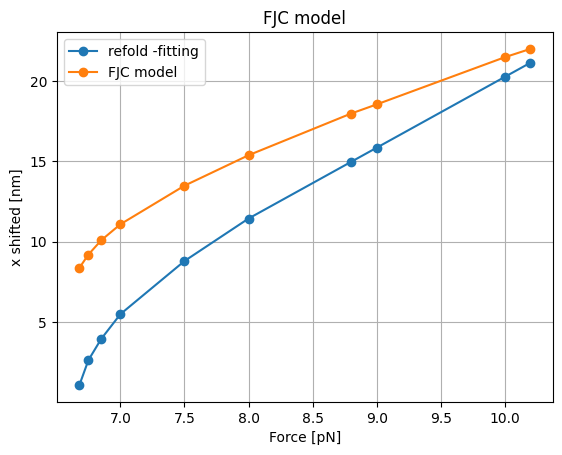

In [ ]:
# REFOLDING - Raul's paper 

# tau = tau_0 exp(-beta * | <x_dag(f)> df)
# WLC:  F_wlc = (kT / lp) * (1 / 4 * (1 - dx / lc)**(-2) + dx / lc - 1/4)

F_list = (6.68, 6.75, 6.85,  7, 7.5, 8, 8.8,  9, 10, 10.2)

plt.plot(F_list, X2_list, marker='o', label= "refold -fitting")
# plt.plot(F_list, X1_list, label="Unfolding", marker='o', linestyle="--", alpha = 0.5)
plt.title("non linear shift in Refoldin process")
plt.grid(True)
plt.ylabel("shift of the 2nd well [nm]")
plt.xlabel("Force (F) [pN]")

# vs FJC model 

lk = 2*lp
force_array = np.array(F_list)

def coth(x):
    x = np.array(x)
    return np.cosh(x) / np.sinh(x)

x_F = lc * (coth(force_array * lk/kT) - kT/ (force_array*lk))
x_shift = x_F - maxima_list
plt.plot(force_array, x_shift, label="FJC model", marker='o')
plt.xlabel("Force [pN]")
plt.ylabel("x shifted [nm]")
plt.title("FJC model")
plt.grid(True)


# # generalized Bell's model - assumo rate MFPT
# tau = 1 / np.array(rate_fold_list)
# d_logtau_dF = np.gradient(np.log(tau), force_array) # Derivata numerica log(tau)
# x_F = -kT * d_logtau_dF
# x_shift = x_F - maxima_list
# plt.plot(force_array, x_shift, label="Generalized Bell's model", marker='o')

plt.legend()
plt.show()


k0 =  43.17234313730489


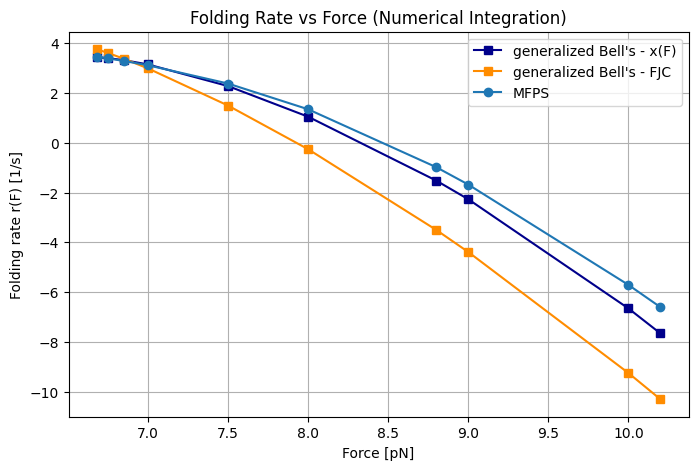

In [ ]:
# GENERAIZED BELL'S MODEL - x as a function of F
## extract rate value as a funcitn of f, k0, l_p, l_c

# fold_fit = linregress(force_list,np.log(rate_fold_list))
# logk0_fold = fold_fit.intercept  
# k0 = np.exp(logk0_fold) 

plt.figure(figsize=(8,5))

# assumo lo shift del well DAL MIO fitting 
integrali = np.array([np.trapz(X2_list[:i+1], F_list[:i+1]) for i in range(len(F_list))])
fit = linregress(-integrali / kT, np.log(rate_fold_list))
logk0_fold = fit.intercept
k0 = np.exp(logk0_fold)

r_F = k0 * np.exp(-integrali / kT)
tau_f = (1/k0) * np.exp ((1/kT) * integrali)
plt.plot(F_list, np.log(1/tau_f), color='darkblue', label = "generalized Bell's - x(F)", marker = "s")

# Assumo x shift da FJC model 
integrali = np.array([np.trapz(x_shift[:i+1], F_list[:i+1]) for i in range(len(F_list))])
fit = linregress(-integrali / kT, np.log(rate_fold_list))
logk0_fold = fit.intercept
k0 = np.exp(logk0_fold)
print ("k0 = ", k0)

r_F = k0 * np.exp(-integrali / kT)
tau_f_fjc = (1/k0) * np.exp ((1/kT) * integrali)
plt.plot(F_list, np.log(1/tau_f_fjc), color='darkorange', label = "generalized Bell's - FJC", marker = "s")

plt.plot(force_list, np.log(rate_fold_list), marker='o', label = "MFPS")
plt.xlabel("Force [pN]")
plt.ylabel("Folding rate r(F) [1/s]")
plt.title("Folding Rate vs Force (Numerical Integration)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# ANALITICAL SOLUTION OF THE INTEGRAL

from scipy.optimize import curve_fit
from scipy.integrate import cumtrapz

force_array = np.array(F_list)
rate_fold_list = np.array(rate_fold_list)

def x_wlc(F, lc, lp):
    return lc * (1 - 0.5 * np.sqrt(kT / (F * lp)))

def model_log_rate(F, lc, lp, logk0):
    x_vals =  x_wlc(F, lc, lp) - maxima_list  # Shifted x values
    integral = cumtrapz(x_vals, F, initial=0)
    return logk0 - integral / kT

popt, _ = curve_fit(model_log_rate, force_array, np.log(rate_fold_list), p0=[45, 0.5, logk0_fold], maxfev=10000)
lc_fit, lp_fit, logk0_fit = popt
k0_fit = np.exp(logk0_fit)

print(f"Fitted l_c = {lc_fit:.2f} nm")
print(f"Fitted l_p = {lp_fit:.3f} nm")
print(f"Fitted k0 = {k0_fit:.4f} 1/s")


Fitted l_c = 70.10 nm
Fitted l_p = 0.238 nm
Fitted k0 = 30.2325 1/s


C:\Users\bulga\AppData\Local\Temp\ipykernel_15144\1253118102.py:10: RuntimeWarning: invalid value encountered in sqrt
  return lc * (1 - 0.5 * np.sqrt(kT / (F * lp)))


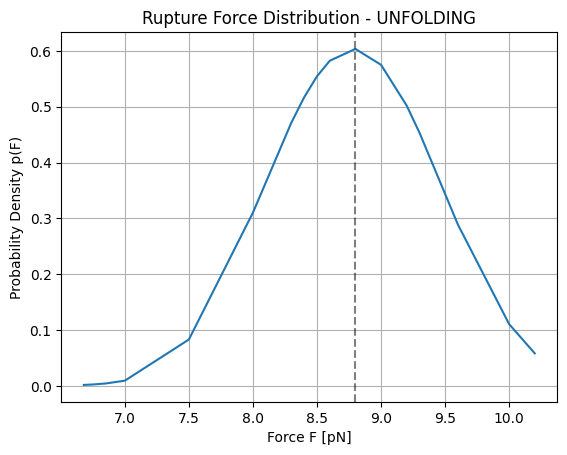

In [ ]:
# PROBABILITY DISTRIBUTION - DUDKO 

from scipy.integrate import cumtrapz

kappa_s = 0.1  # stiffness della molla [pN/nm]
v = 100        # velocità [nm/s]
F_dot = kappa_s * v  # loading rate costante
#########-------------ASK_RAFA


tau_list = [1 / k for k in rate_unfold_list]

x = F_list
tau_array = np.array(tau_list)
y = 1 / (F_dot * tau_array)
integral = cumtrapz(y, x, initial=0)  # integrale comulativo reg trapezio
p_F = np.exp(-integral) / (F_dot * tau_array)

# Normalizzazione: ∫p(F)dF = 1
area = np.trapz(p_F, x)
p_F_normalized = p_F / area

# Plot
plt.plot(x, p_F_normalized)
plt.xlabel("Force F [pN]")
plt.ylabel("Probability Density p(F)")
plt.axvline(x = 8.8, linestyle='--', c ="black",  alpha = 0.5)
plt.title("Rupture Force Distribution - UNFOLDING")
plt.grid(True)
plt.show()
